# 실습 2. DBSCAN 군집화

`make_circles`로 만든 원형 데이터에서 DBSCAN의 밀도 기반 군집화를 연습함.

## 데이터셋
- 데이터: scikit-learn `make_circles`
- 샘플 수: 350개
- feature 수: 2개
- 구조: 안쪽 원과 바깥쪽 원 2개

데이터 생성 코드는 제공됨. 문제에서는 교안에서 배운 `StandardScaler`, `KMeans`, `DBSCAN`, `eps`, `min_samples`, 시각화 흐름만 사용함.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

circle_X, circle_y = make_circles(
    n_samples=350,
    noise=0.04,
    factor=0.45,
    random_state=42
)

circle_df = pd.DataFrame(circle_X, columns=['feature_1', 'feature_2'])
circle_df['true_group'] = circle_y

display(circle_df.head())
print('circle_X shape:', circle_X.shape)
display(circle_df['true_group'].value_counts().sort_index().to_frame('count'))


,feature_1,feature_2,true_group
0,0.818937,-0.448104,0
1,0.449546,-0.097471,1
2,0.177218,-0.401920,1
3,-0.246874,0.414573,1
4,0.722158,-0.667411,0


circle_X shape: (350, 2)


,count
true_group,
0,175
1,175


## 문제 1. 원형 데이터 시각화와 스케일링

원형 데이터의 실제 그룹 분포를 산점도로 확인하고, `StandardScaler`로 스케일링하세요.

요구사항:
- 변수명은 `circle_scaler`, `circle_X_scaled`, `circle_scaled_df` 사용
- 산점도는 `true_group` 기준으로 색상 표시

### 실행 결과
```text
scaled mean: 0.0
scaled std: 1.0
그래프 제목: Circle Data: True Group for Interpretation
```


scaled mean: -0.0
scaled std: 1.0


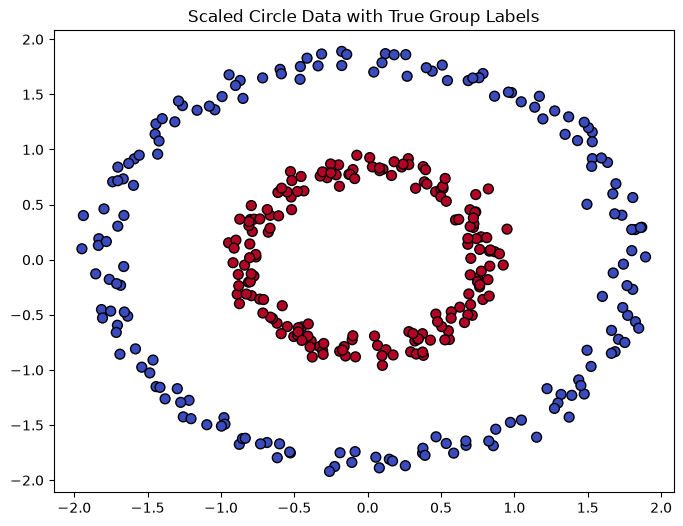

In [3]:

circle_scaler = StandardScaler()
circle_X_scaled = circle_scaler.fit_transform(circle_X)

circle_scaled_df = pd.DataFrame(circle_X_scaled, columns=['feature_1', 'feature_2'])
circle_scaled_df['true_group'] = circle_y

plt.figure(figsize=(8, 6))
plt.scatter(
  circle_scaled_df['feature_1'], 
  circle_scaled_df['feature_2'], 
  c=circle_scaled_df['true_group'], 
  cmap='coolwarm', 
  edgecolor='k', s=50)

print('scaled mean:', circle_X_scaled.mean().round(1))
print('scaled std:', circle_X_scaled.std().round(1))

plt.title('Scaled Circle Data with True Group Labels')
plt.show()

## 문제 2. KMeans와 DBSCAN 결과 비교

같은 원형 데이터에 KMeans와 DBSCAN을 각각 적용하고 결과를 비교하세요.

요구사항:
- KMeans는 `n_clusters=2`, `n_init=10`, `random_state=42`
- DBSCAN은 `eps=0.32`, `min_samples=5`
- 결과를 `circle_compare_df`에 저장
- 두 결과를 나란히 산점도로 시각화

### 실행 결과
```text
KMeans cluster count 예시: {0: 180, 1: 170}
DBSCAN label count 예시: {0: 175, 1: 175}
그래프 제목:
- KMeans on Circle Data
- DBSCAN on Circle Data
```


,feature_1,feature_2,kmeans_cluster,dbscan_cluster
0,1.495203,-0.821104,1,0
1,0.819616,-0.180495,1,1
2,0.321551,-0.736726,1,1
3,-0.454076,0.755014,0,1
4,1.318203,-1.221781,1,0


KMeans cluster count 예시: {0: 178, 1: 172}
DBSCAN label count 예시: {0: 175, 1: 175}


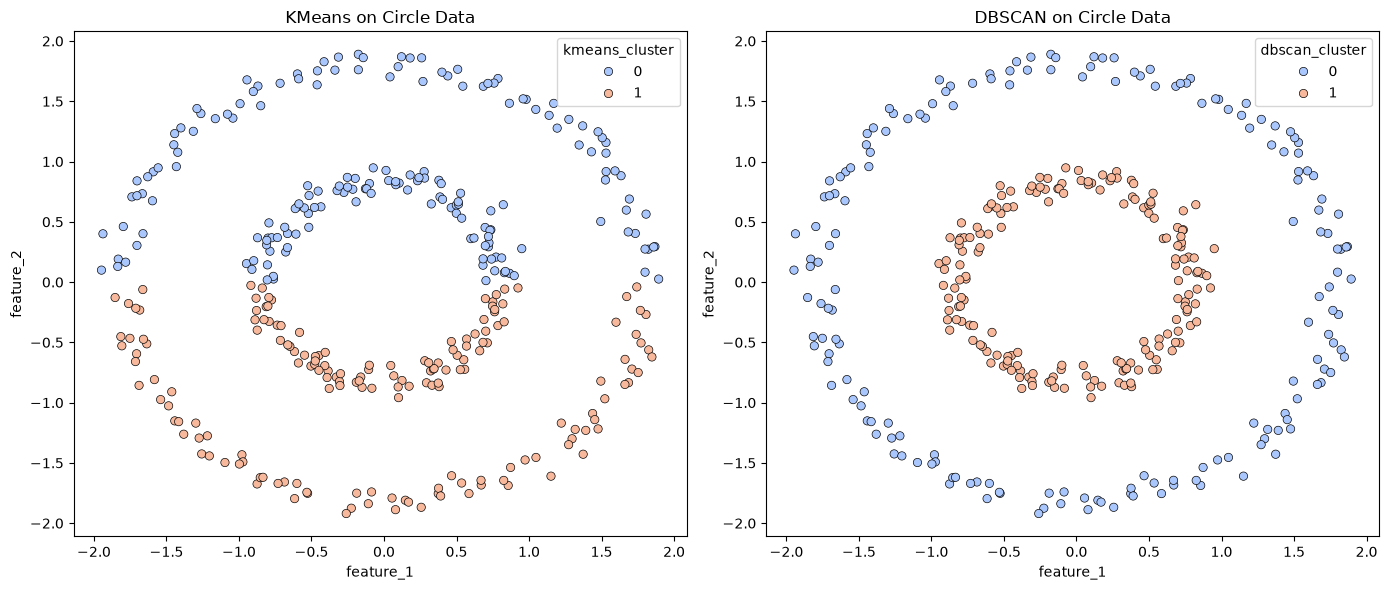

In [26]:
kmeans = KMeans(
  # 군집의 개수
  n_clusters=2,
  n_init=10,
  random_state=42)
# 학습 후 바로 예측하여 moon_kmeans_labels에 저장합니다.
circle_kmeans_labels = kmeans.fit_predict(circle_X_scaled)

# DBSCAN: eps 반경 내에 min_samples 이상의 이웃 데이터가 있으면 같은 밀도 영역으로 봄 
dbscan = DBSCAN(eps=0.32, min_samples=5)
circle_dbscan_labels = dbscan.fit_predict(circle_X_scaled)

circle_compare_df = pd.DataFrame(circle_X_scaled, columns=['feature_1', 'feature_2'])
circle_compare_df['kmeans_cluster'] = circle_kmeans_labels
circle_compare_df['dbscan_cluster'] = circle_dbscan_labels

display(circle_compare_df.head())

print('KMeans cluster count 예시:', circle_compare_df['kmeans_cluster'].value_counts().sort_index().to_dict())
print('DBSCAN label count 예시:', circle_compare_df['dbscan_cluster'].value_counts().sort_index().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
  data=circle_compare_df,
  x='feature_1',
  y='feature_2',
  hue='kmeans_cluster',
  palette='coolwarm',
  edgecolor='black',
  ax=axes[0]
)
axes[0].set_title('KMeans on Circle Data')

sns.scatterplot(
  data=circle_compare_df,
  x='feature_1',
  y='feature_2',
  hue='dbscan_cluster',
  palette='coolwarm',
  edgecolor='black',
  ax=axes[1]
)
axes[1].set_title('DBSCAN on Circle Data')

plt.tight_layout()
plt.show()

## 문제 3. `eps`, `min_samples` 변화 비교

DBSCAN의 `eps`, `min_samples` 설정을 바꾸며 군집 개수와 노이즈 개수를 비교하세요.

요구사항:
- 후보: `(0.16, 5)`, `(0.24, 5)`, `(0.32, 5)`, `(0.70, 5)`, `(0.32, 10)`
- 결과 컬럼: `eps`, `min_samples`, `cluster_count`, `noise_count`
- 결과 변수명은 `circle_param_result_df`

### 실행 결과
```text
    eps  min_samples  cluster_count  noise_count
0  0.16            5             20           54
1  0.24            5              6            0
2  0.32            5              2            0
3  0.70            5              1            0
4  0.32           10              8            5
```


In [27]:

# eps(앱실론), min_samples의 변화에 따라 DBSCAN 결과가 어떻게 달라지는지 비교
circle_param_result=[]
param_candidates=[
  {'eps':0.16, 'min_samples':5},
  {'eps':0.24, 'min_samples':5},
  {'eps':0.32, 'min_samples':5},
  {'eps':0.70, 'min_samples':5},
  {'eps':0.32, 'min_samples':10},
]

for params in param_candidates:
  # print(params)
  model = DBSCAN(
    eps=params['eps'],
    min_samples=params['min_samples']
  )

  # # DBSCAN 모델 학습 후 예측
  labels = model.fit_predict(circle_X_scaled)
  # # 군집 개수
  cluster_count = len(set(labels) - {-1})
  # # 노이즈의 개수
  noise_count = np.sum(labels == -1)

  circle_param_result.append({
    'eps':params['eps'],
    'min_samples':params['min_samples'],
    'cluster_count':cluster_count,
    'noise_count':noise_count
  })
# circle_param_result
circle_param_result_df = pd.DataFrame(circle_param_result)
display(circle_param_result_df)

,eps,min_samples,cluster_count,noise_count
0,0.16,5,20,54
1,0.24,5,6,0
2,0.32,5,2,0
3,0.70,5,1,0
4,0.32,10,8,5


## 문제 4. 최종 DBSCAN 결과 해석

`eps=0.32`, `min_samples=5` 결과를 실제 `true_group`과 교차표로 비교하세요.

요구사항:
- `pd.crosstab()` 사용
- 행은 실제 그룹, 열은 DBSCAN label
- 결과 변수명은 `circle_dbscan_table`

### 실행 결과
```text
dbscan_cluster    0    1
true_group              
0               175    0
1                 0  175
```


In [25]:
# 실제 그룹(true_group)과 DBSCAN 군집 결과(dbscan_cluster)를 비교하기 위해 교차표를 생성합니다.
# 행(index): 실제 정답 그룹
# 열(columns): DBSCAN이 예측한 군집 라벨
# 표 안의 값: 해당 실제 그룹에 속하면서 동시에 해당 DBSCAN 라벨로 분류된 데이터 개수
circle_dbscan_table = pd.crosstab(
  index=circle_y,
  columns=circle_dbscan_labels,
  rownames=['true_group'],
  colnames=['dbscan_cluster']
)

circle_dbscan_table

  # 예를 들어 결과가 아래처럼 나오면:

  # dbscan_cluster    0    1
  # true_group
  # 0               175    0
  # 1                 0  175

  # 의미는 다음과 같습니다.

  # 실제 그룹 0인 데이터 175개가 DBSCAN 라벨 0으로 분류됨
  # 실제 그룹 0인 데이터 0개가 DBSCAN 라벨 1로 분류됨
  # 실제 그룹 1인 데이터 0개가 DBSCAN 라벨 0으로 분류됨
  # 실제 그룹 1인 데이터 175개가 DBSCAN 라벨 1로 분류됨

  # 즉 이 결과에서는 DBSCAN이 실제 원형 그룹을 거의 정확하게 나눈 것으로 해석할 수 있습니다.

dbscan_cluster,0,1
true_group,,
0,175,0
1,0,175
